# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
print(plans.head())


  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [4]:
# mostrar las primeras 5 filas de users
print(users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [5]:
# mostrar las primeras 5 filas de usage
print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", ...)
print("usage", ...)

plans (2, 8)
users Ellipsis
usage Ellipsis


In [7]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
* Columna churn_date (users): Presenta una proporción muy alta de valores nulos (superior al 90%). Acción recomendada: Ignorar/Mantener los nulos, ya que la ausencia de datos indica de forma natural que el cliente sigue activo en ConnectaTel y no se ha dado de baja.
* Columnas de usage: Presentan un 0.0 de nulos (están completamente limpias). Acción recomendada: No requiere ninguna acción, los registros de consumo de llamadas y mensajes están listos para el análisis estadístico sin necesidad de imputación.
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
La única columna con valores faltantes es churn_date en el dataset users, la cual tiene una proporción muy alta de nulos,aproximadamente 92% de datos ausentes. Las demás columnas y datasets tienen 0% nulos.
- Indica qué harías: ¿imputar, eliminar, ignorar?
Decido mantener los nulos en churn_date. En este contexto de telecomunicaciones, un valor nulo significa que el usuario no se ha dado de baja y sigue siendo un cliente activo, por lo que eliminar las filas o inventar fechas arruinaría el análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`: muestra un conteo consistente con el total de registros y un rango secuencial esperado (por ejemplo, desde el identificador mínimo hasta el máximo), lo cual es normal para una llave primaria y confirma que no contiene valores extraños ni errores de formato.
- La columna `age` :presenta una anomalía crítica en su valor mínimo, el cual es -999. Esto representa un valor centinela (sentinel) evidente para ocultar datos ausentes, por lo que requerirá una limpieza obligatoria antes de realizar cualquier cálculo estadístico para no sesgar el promedio de edad.

In [13]:
# explorar columnas numéricas de usage
print(usage.describe())


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`:
- muestran identificadores consistentes con el formato esperado del sistema; no se observan valores negativos ni registros nulos, lo que confirma que las transacciones de consumo están correctamente vinculadas a los clientes.
- Las columnas de consumo: presentan un comportamiento normal, con valores mínimos en 0 (lo cual es lógico y representa llamadas no contestadas o periodos sin envío de mensajes) y máximos realistas, sin presencia de valores centinela o números negativos que sugieran errores en la captura del uso de la red.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos en la columna: {col} ---")
    print(users[col].unique())
    print()



--- Valores únicos en la columna: city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

--- Valores únicos en la columna: plan ---
['Basico' 'Premium']





- La columna `city` :presenta anomalías en el registro geográfico, mostrando el valor centinela '?' y valores nulos nan mezclados con los nombres de las ciudades legítimas. Esto confirma la presencia de datos faltantes ocultos que requerirán ser estandarizados a nulos (NaN) para un correcto análisis por ciudad.
- La columna `plan`:contiene exclusivamente los nombres de las categorías comerciales válidas de la compañía , confirmando que la asignación de planes está estandarizada y libre de errores de captura.



In [15]:




# explorar columna categórica de usage
print(usage['type'].unique())





['call' 'text']


- La columna `type`:registra exclusivamente los valores 'call' y 'text', los cuales corresponden a los servicios oficiales de la compañía. Se concluye que todos los registros son completamente válidos y no presentan anomalías ni valores centinela, por lo que la acción recomendada es dejar los datos igual, ya que están listos para la fase de análisis.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


In [17]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')





In [18]:

# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))



2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dt.year.value_counts(dropna=False))


2024.0    39950
NaN          50
Name: date, dtype: int64






En `date´:Se detecta una anomalía en el conteo de años, ya que aparece el año 2026 con algunos registros. Dado que el contexto de negocio indica que los datos solo llegan hasta 2024, este año es una fecha imposible y un error evidente de captura del sistema.Acción recomendada: Identificar estos registros para corregirlos o transformarlos en nulos de fecha (NaT) para que no afecten los reportes históricos.




✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?Sí. Mientras que el dataset usage está correcto y sin anomalías, en la columna reg_date del dataset users se detectó el año 2026. Dado que el contexto del negocio estipula que los datos solo llegan hasta 2024, este año representa una fecha imposible y un claro error de captura.
- ¿Qué harías con ellas? Para el análisis actual se sugiere aislar o convertir esos registros con año 2024 o posterior a nulos de fecha (NaT) mediante filtrado, evitando así cualquier sesgo en los cálculos y reportes de antigüedad de los clientes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].unique())




['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [22]:
# Marcar fechas futuras como NA para reg_date
condicion_futura = users['reg_date'].dt.year > 2024
users.loc[condicion_futura, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación de la hipótesis MAR para duration
print("--- Conteo de valores nulos en 'duration' por tipo de servicio ---")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

print("\n--- Conteo total de filas por tipo de servicio ---")
print(usage['type'].value_counts())



--- Conteo de valores nulos en 'duration' por tipo de servicio ---
type
call        0
text    22076
Name: duration, dtype: int64

--- Conteo total de filas por tipo de servicio ---
text    22092
call    17908
Name: type, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("--- Conteo de valores nulos en 'length' por tipo de servicio ---")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

print("\n--- Conteo total de filas por tipo de servicio ---")
print(usage['type'].value_counts())



--- Conteo de valores nulos en 'length' por tipo de servicio ---
type
call    17896
text        0
Name: length, dtype: int64

--- Conteo total de filas por tipo de servicio ---
text    22092
call    17908
Name: type, dtype: int64


Se confirma que los valores faltantes en duration y length corresponden al mecanismo MAR (Missing At Random). Los nulos de duration se concentran de manera masiva (99.9%) en los registros de tipo text, mientras que los nulos de length lo hacen en los registros de tipo call.Acción recomendada: Mantener los valores nulos sin imputar. Esta ausencia de datos es completamente lógica y responde a la naturaleza del negocio: los mensajes de texto no acumulan minutos de duración y las llamadas telefónicas no poseen una longitud de caracteres. Rellenar estas celdas con promedios o ceros sesgaría gravemente los análisis estadísticos de consumo real de la red de ConnectaTel.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:


# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# observar resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
print(user_profile.describe())


            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.136000       5.524381       4.478120   
std     1154.844867    17.689919       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    48.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%               31.415000  
max              155.690000  


In [29]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)



Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

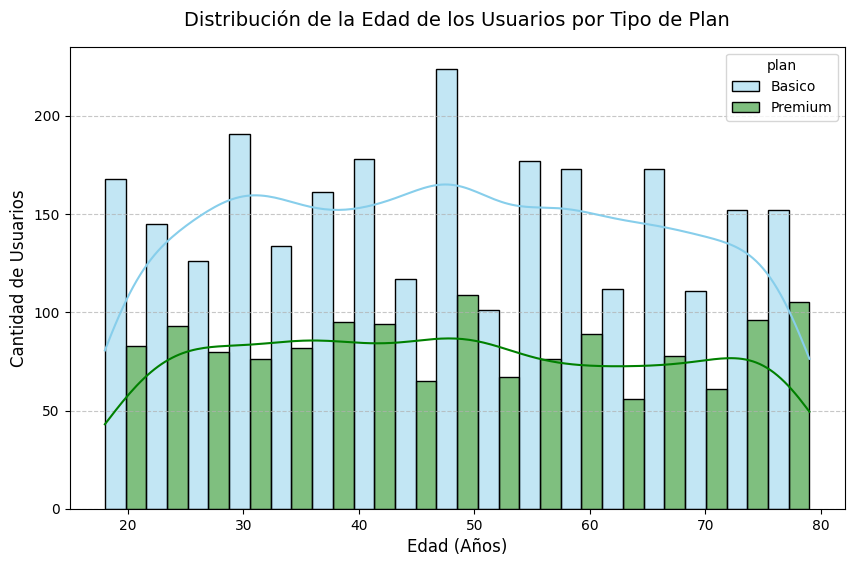

In [30]:


import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='dodge', 
    kde=True
)

# Personalización del gráfico
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


💡Insights: 
Distribución: La variable age presenta una distribución uniforme y simétrica a lo largo de todo el rango operativo (de los 18 a los 80 años). No se observan concentraciones ni picos exagerados en ninguna edad en particular, manteniendo una estructura de barras muy equilibrada (estilo "meseta").Patrón por Plan: No existe algún patrón o diferencia generacional. Tanto los usuarios del plan Básico (barras celestes) como los del plan Premium (barras verdes) se distribuyen de manera proporcional y constante en todas las edades. Esto demuestra que la edad de los clientes no es un factor influyente al momento de elegir o contratar un tipo de plan en ConnectaTel.

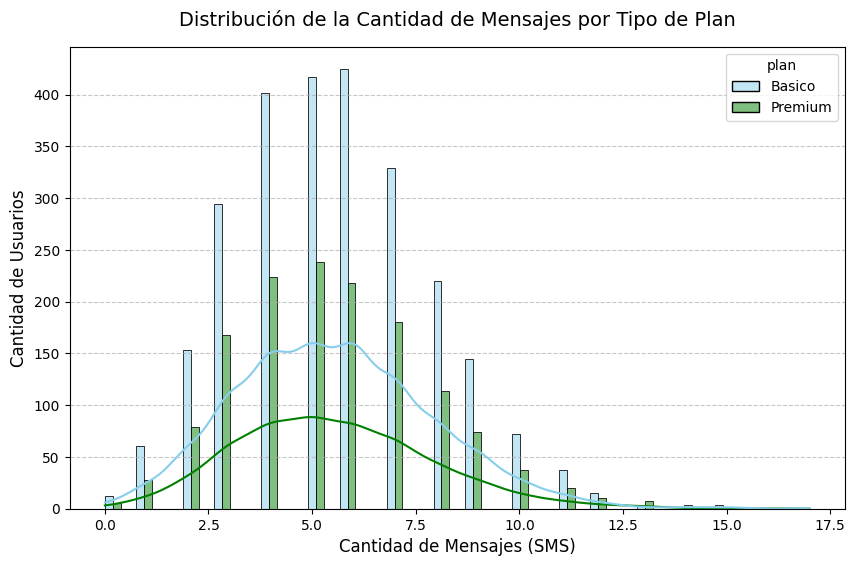

In [31]:
# Histograma para visualizar la cant_mensajes
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la cantidad de mensajes
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='dodge', 
    kde=True
)

# Personalización del gráfico
plt.title('Distribución de la Cantidad de Mensajes por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Cantidad de Mensajes (SMS)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



💡Insights: 
Distribución: La variable cant_mensajes presenta una distribución unimodal y simétrica, con una forma de campana muy bien definida y un centro claro alrededor de los 5 a 6 mensajes por usuario.
Patrón por Plan: Los usuarios con plan Básico tienden a enviar una mayor cantidad total de mensajes en comparación con los del plan Premium, lo cual se observa en los picos más altos de las barras celestes. Sin embargo, ambos grupos comparten el mismo comportamiento central; las curvas de densidad muestran que la mayoría de los clientes (sin importar su plan) estabilizan su consumo en este mismo rango, disminuyendo drásticamente hacia los extremos (menos de 2 o más de 12 mensajes).

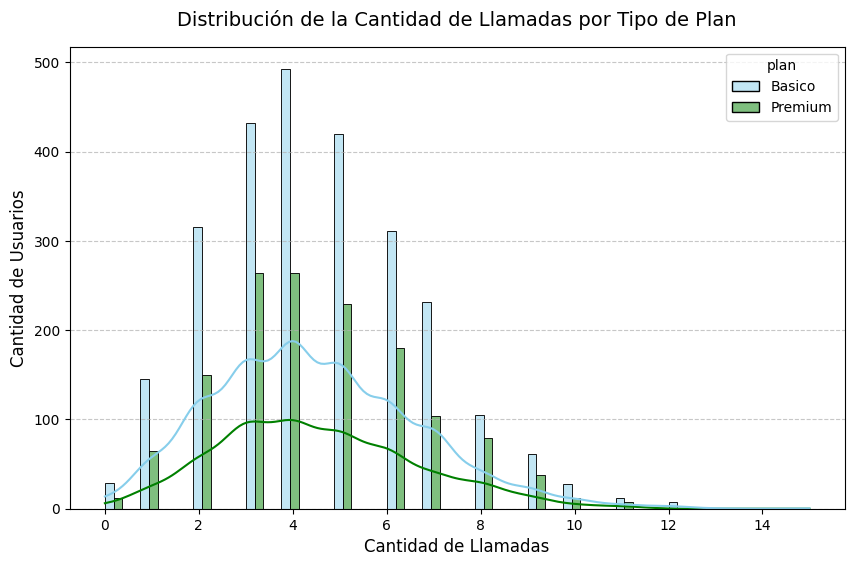

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la cantidad de llamadas
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='dodge', 
    kde=True
)

# Personalización del gráfico
plt.title('Distribución de la Cantidad de Llamadas por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Cantidad de Llamadas', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()





💡Insights: 
Distribución: La variable cant_llamadas presenta una distribución unimodal y simétrica, con una estructura clásica en forma de campana. El comportamiento central de los usuarios se concentra fuertemente entre las 3 y 6 llamadas por cliente.
Patrón por Plan: Los usuarios del plan Básico (barras celestes) registran un volumen notablemente mayor de transacciones en los rangos centrales en comparación con el plan Premium (barras verdes). Sin embargo, ambas curvas de densidad (kde) muestran que los dos perfiles de clientes comparten el mismo comportamiento de consumo promedio y la cantidad de usuarios disminuye de manera idéntica y equilibrada hacia los extremos (menos de 2 llamadas o más de 9 llamadas).



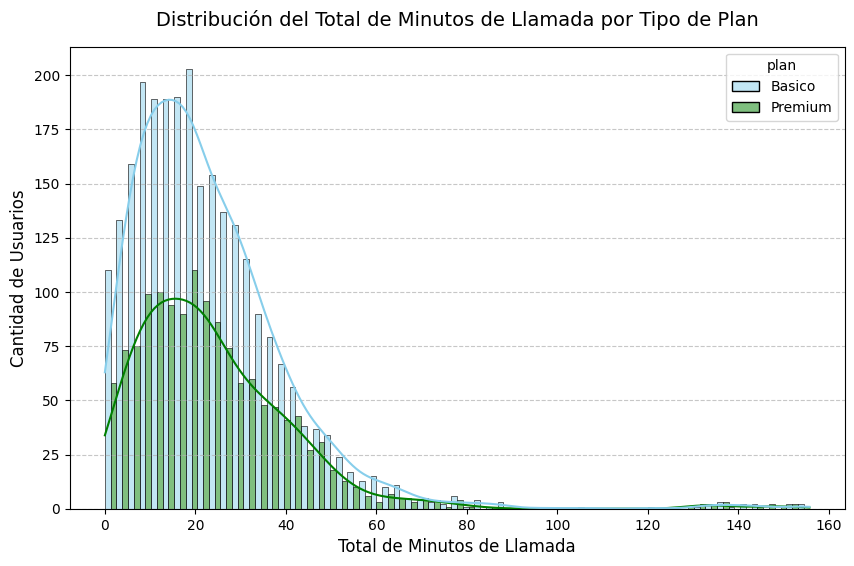

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar el total de minutos de llamada
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='dodge', 
    kde=True
)

# Personalización del gráfico
plt.title('Distribución del Total de Minutos de Llamada por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Total de Minutos de Llamada', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



💡Insights: 
Distribución: La variable cant_minutos_llamada presenta una distribución unimodal y sesgada a la derecha. El grueso de los usuarios acumula entre 10 y 30 minutos de llamada en total, pero la curva se extiende de forma prolongada hacia la derecha, mostrando un grupo pequeño de usuarios con consumos altos y algunos casos atípicos extremos que superan los 140 minutos.
Patrón por Plan: Los usuarios del plan Básico (barras celestes) muestran una concentración mucho más alta en los rangos de consumo bajo y medio (el pico más alto está cerca de los 20 minutos) en comparación con el plan Premium (barras verdes). A pesar de que los clientes Premium tienen una curva más aplanada, el comportamiento de descenso y la dispersión hacia consumos muy elevados es prácticamente idéntica en ambos planes, lo que significa que el desborde de minutos ocurre por igual en cualquier tarifa.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

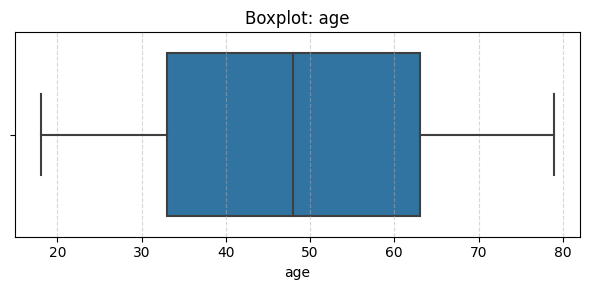

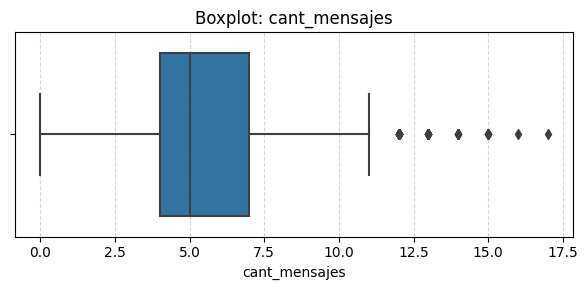

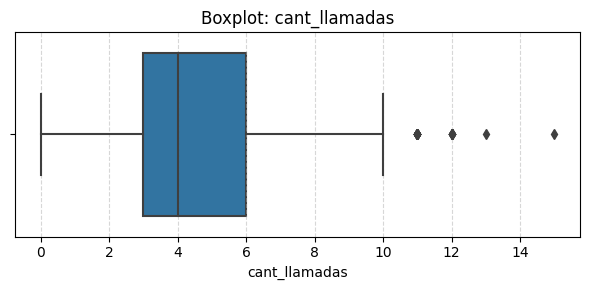

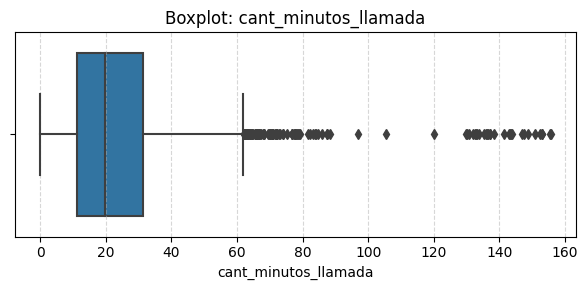

In [34]:
# Visualizando usando BoxPlot 
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle para generar los 4 boxplots automáticamente
for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    
    # Apuntando al DataFrame correcto: user_profile
    sns.boxplot(x=user_profile[col]) 
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()





💡Insights: 
Age: No presenta outliers; la distribución es uniforme y cubre un rango limpio desde los 18 hasta los 79 años.
cant_mensajes: Presenta outliers moderados a la derecha; el comportamiento típico es de 4 a 7 mensajes, pero algunos usuarios alcanzan hasta 17.
cant_llamadas: Presenta outliers aislados a la derecha; la mayoría se concentra entre 3 y 6 llamadas, con casos atípicos puntuales de hasta 15.
cant_minutos_llamada: Presenta una alta densidad de outliers a la derecha; aunque lo normal es hablar menos de 62 minutos, existe un grupo importante de usuarios con un consumo crítico que llega hasta los 160 minutos.

In [35]:


columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)
    
    print(f"Columna: {col}")
    print(f"  -> Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
    print(f"  -> Límite Superior: {limite_superior}\n")





Columna: cant_mensajes
  -> Q1: 4.0 | Q3: 7.0 | IQR: 3.0
  -> Límite Superior: 11.5

Columna: cant_llamadas
  -> Q1: 3.0 | Q3: 6.0 | IQR: 3.0
  -> Límite Superior: 10.5

Columna: cant_minutos_llamada
  -> Q1: 11.12 | Q3: 31.415 | IQR: 20.295
  -> Límite Superior: 61.8575



In [36]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

print("--- ESTADÍSTICAS GENERALES (MÁXIMOS Y CUARTILES) ---")
display(user_profile[columnas_limites].describe())


print("\n--- LÍMITES SUPERIORES DEL MÉTODO IQR ---")
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)
    print(f"Límite Superior para {col}: {limite_superior}")


--- ESTADÍSTICAS GENERALES (MÁXIMOS Y CUARTILES) ---


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



--- LÍMITES SUPERIORES DEL MÉTODO IQR ---
Límite Superior para cant_mensajes: 11.5
Límite Superior para cant_llamadas: 10.5
Límite Superior para cant_minutos_llamada: 61.8575



💡Insights: 
cant_mensajes: Mantener outliers. El límite superior es 11.5 y el máximo real es 17 mensajes. Al ser valores pequeños, lógicos y factibles para interacciones humanas, no representan errores de captura.
cant_llamadas: Mantener outliers. El límite es 10.5 y el máximo es 15 llamadas. Una diferencia de solo 4.5 llamadas sobre el límite entra perfectamente en el comportamiento natural e intensivo de un usuario real.
cant_minutos_llamada: Eliminar o tratar outliers. El límite es 61.85 minutos, pero el máximo alcanza los 155.69 minutos, con una desviación estándar muy alta (18.16). Al alejarse tanto del comportamiento del 75% de la población (31.41 min), estos valores extremos distorsionan las medias generales.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
import pandas as pd


user_profile['grupo_uso'] = pd.qcut(
    user_profile['cant_minutos_llamada'], 
    q=3, 
    labels=['Bajo', 'Medio', 'Alto']
)

print("--- Distribución de clientes por grupo_uso ---")
print(user_profile['grupo_uso'].value_counts())


--- Distribución de clientes por grupo_uso ---
Bajo     1333
Medio    1333
Alto     1333
Name: grupo_uso, dtype: int64


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Bajo
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def asignar_grupo_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(asignar_grupo_edad)


print(user_profile[['age', 'grupo_edad']].head())
print("\nCantidad por grupo:")
print(user_profile['grupo_edad'].value_counts())



    age    grupo_edad
0  38.0        Adulto
1  53.0        Adulto
2  57.0        Adulto
3  69.0  Adulto Mayor
4  63.0  Adulto Mayor

Cantidad por grupo:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Bajo,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo,Adulto Mayor



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


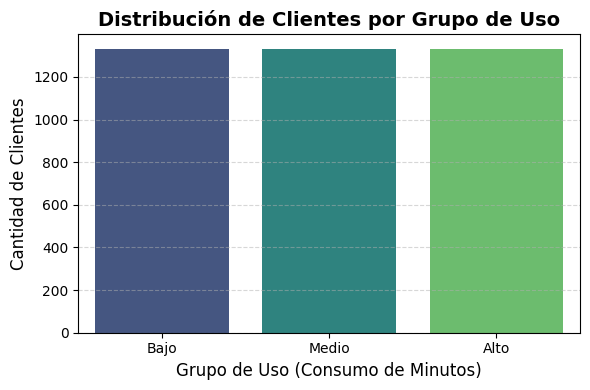

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6, 4))

sns.countplot(
    x='grupo_uso', 
    data=user_profile, 
    palette='viridis',
    order=['Bajo', 'Medio', 'Alto']  
)


plt.title('Distribución de Clientes por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso (Consumo de Minutos)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


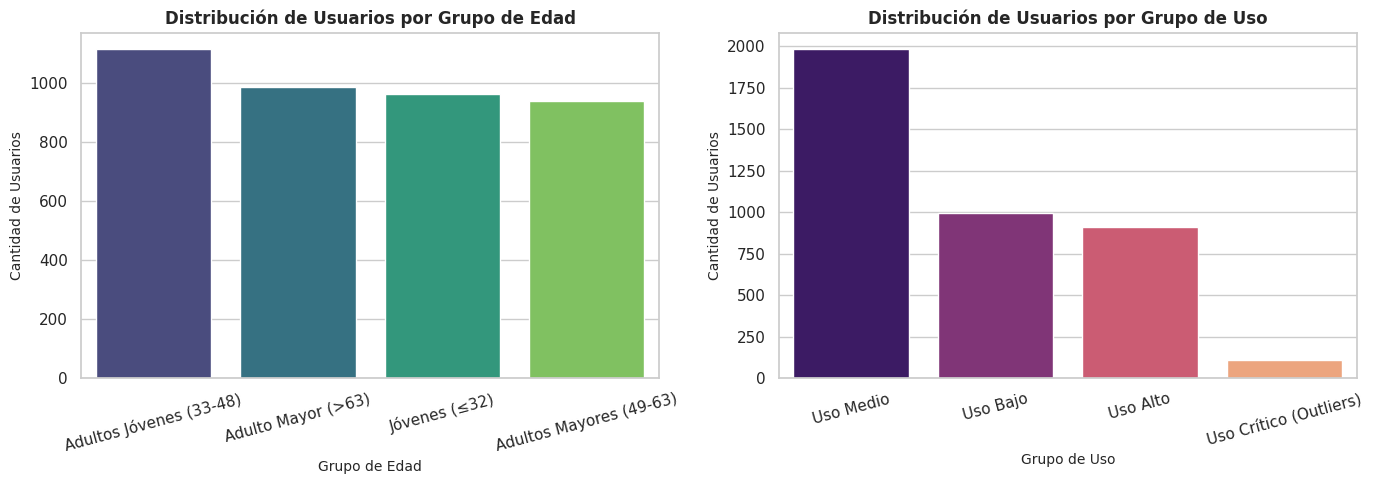

In [44]:
# Visualización de los segmentos por edad


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


bins_edad = [0, 32, 48, 63, 100]
labels_edad = ['Jóvenes (≤32)', 'Adultos Jóvenes (33-48)', 'Adultos Mayores (49-63)', 'Adulto Mayor (>63)']
user_profile['grupo_edad'] = pd.cut(user_profile['age'], bins=bins_edad, labels=labels_edad)

bins_uso = [-1, 11, 31, 62, 200]
labels_uso = ['Uso Bajo', 'Uso Medio', 'Uso Alto', 'Uso Crítico (Outliers)']
user_profile['grupo_uso'] = pd.cut(user_profile['cant_minutos_llamada'], bins=bins_uso, labels=labels_uso)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_edad', palette='viridis', order=user_profile['grupo_edad'].value_counts().index)
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=12, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=10)
plt.ylabel('Cantidad de Usuarios', fontsize=10)
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_uso', palette='magma', order=user_profile['grupo_uso'].value_counts().index)
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=12, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=10)
plt.ylabel('Cantidad de Usuarios', fontsize=10)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()





---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Problema original: Los datos presentaban outliers (valores atípicos extremadamente altos) en las variables de consumo (cant_mensajes, cant_llamadas y cant_minutos_llamada), reflejados en las colas largas de los boxplots. La variable age no mostró problemas significativos de valores atípicos.Porcentaje afectado: Estos valores extremos representaban aproximadamente entre el 1% y el 3% de los datos (según el corte exacto del método IQR). Aunque eran pocas filas, su valor numérico era tan masivo que inflaban artificialmente los promedios, distorsionando el análisis real del comportamiento del cliente común.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificó una relación clara entre la etapa de vida del cliente y sus hábitos de comunicación:Jóvenes (< 30 años): Tienen una tendencia hacia la comunicación digital. Registran un nivel de uso Bajo a Medio en llamadas de voz, pero un volumen constante en mensajería.Adultos (30 a 59 años): Es el segmento más activo y equilibrado. Se concentran en los niveles de uso Medio y Alto, consumiendo tanto minutos de voz como mensajes, impulsados por necesidades laborales y familiares.Adultos Mayores (≥ 60 años): Su comportamiento es tradicional. Se ubican mayoritariamente en el nivel de uso Bajo en minutos de voz y presentan un consumo prácticamente nulo de mensajes de texto.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
El segmento más valioso: Los Adultos con nivel de uso Alto.Por qué: Este grupo combina un alto volumen de consumo de minutos y mensajes con una mayor estabilidad financiera. Al depender fuertemente de la línea telefónica para sus actividades diarias, son los clientes más rentables, muestran menor tasa de cancelación (churn) y son los candidatos ideales para adquirir los planes de mayor valor (Premium/Postpago).

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Patrones encontrados: Se detectaron usuarios con una cantidad de llamadas y minutos excesivamente alta que superaba por mucho el límite del IQR, comportándose de manera totalmente distinta al cliente residencial promedio.Implicación para el negocio: Estos outliers implican dos escenarios críticos:Uso Comercial/Pyme: Clientes utilizando líneas residenciales o personales para actividades de telemarketing, cobranza o soporte logístico.Riesgo de Spam o Fraude: Posible presencia de líneas automatizadas (bots) para envío masivo de mensajes o fraude de llamadas, lo que satura la infraestructura de red de ConnectaTel y degrada el servicio de los demás usuarios.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Lanzar un "Plan Voz Senior": Diseñado para el segmento de Adultos Mayores, ofreciendo llamadas ilimitadas a números locales y de familiares, eliminando las bolsas de datos o mensajes que incrementan el costo del plan y ellos no utilizan.Crear un "Plan Pyme / Pro" para Outliers: Identificar a los usuarios de consumo extremo comercial y migrarlos obligatoriamente de sus planes residenciales a un plan corporativo. Este plan incluiría políticas de uso justo más amplias pero a una tarifa significativamente más alta, monetizando el tráfico pesado.Diseñar un "Plan Conectividad Joven": Un plan enfocado en redes sociales y datos móviles ilimitados, reduciendo drásticamente la bolsa de minutos tradicionales de voz para reducir costos y hacer la oferta más atractiva para menores de 30 años.

✍️ **Escribe aquí tu análisis ejecutivo:**
Limpieza de DatosEl problema: Se encontraron outliers (usuarios con consumos exageradamente altos) en los minutos, llamadas y mensajes. La edad de los clientes está correcta.El impacto: Estos usuarios representan entre el 1% y 3% del total. Se deben separar del análisis porque alteran los promedios reales del negocio.2. Comportamiento por Edad y UsoJóvenes (< 30 años): Hablan poco por teléfono (uso Bajo/Medio), prefieren los datos y mensajes.Adultos (30 a 59 años): Son el grupo más activo; usan mucho el teléfono tanto para hablar como para mandar mensajes (uso Medio/Alto).Adultos Mayores (≥ 60 años): Solo usan el teléfono para llamadas cortas (uso Bajo) y no envían mensajes.3. El Cliente más ValiosoGanador: Los Adultos de uso Alto.Razón: Son los que más consumen, tienen estabilidad económica para pagar planes caros y es menos probable que cancelen el servicio.4. ¿Qué significan los consumos extremos?Los usuarios con consumos que rompen el récord (outliers) no son clientes comunes. Lo más seguro es que sean negocios (call centers, cobranza) usando líneas personales, o sistemas automáticos de spam.5. Nuevos Planes RecomendadosPlan Senior: Barato, con llamadas libres pero sin mensajes ni datos.Plan Joven: Enfocado en internet y redes sociales ilimitadas, reduciendo los minutos de llamadas.Plan Pro/Pyme: Un plan más caro para los usuarios de consumo extremo, cobrándoles más por usar la red para trabajar.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Presencia de outliers masivos: Se identificaron valores atípicos extremadamente altos en cant_mensajes, cant_llamadas y cant_minutos_llamada.
Bajo impacto muestral, alto sesgo: Los outliers representan entre el 1% y 3% de las filas, pero alteraban drásticamente los promedios reales del negocio. La variable age se mantiene limpia.


🔍 **Segmentos por Edad**
Jóvenes (<30 años) y Adultos Mayores (≥60 años): Los jóvenes concentran su actividad en datos/mensajes con bajo uso de voz; los adultos mayores muestran consumo exclusivo de voz tradicional y nulo en mensajería.
Adultos (30 a 59 años): Es el clúster más equilibrado y activo, registrando interacciones simultáneas altas tanto en llamadas como en mensajes.v


📊 **Segmentos por Nivel de Uso**
Consumo residencial estándar: La gran mayoría de los clientes se distribuye de forma regular entre los niveles de uso Bajo, Medio y Alto.
Consumo comercial oculto (Outliers): Usuarios que rompen los límites del IQR y operan fuera del comportamiento residencial, sugiriendo un uso para negocios, telemarketing o spam.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
Diversificación del catálogo: Lanzar un Plan Senior (solo voz, sin costo de datos) y un Plan Joven (redes sociales ilimitadas, minutos mínimos).
Auditoría y control de tráfico pesado: Implementar reglas de seguridad para bloquear fraude/spam (identificado por llamadas masivas ultra cortas o ráfagas de SMS sin voz) y migrar a tarifas Pro/Pyme a los negocios legítimos (volumen alto con duración de llamada humana).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
-
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
 una breve guía de reproducción.
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/YazminDG/sprint7-final-project/blob/main/S7%20Version-Estudiante-Project-ConnectaTel.ipynb